# Phase 2 | Pre-Experiment Power Analysis and Propensity Score Matching

**Project**: Beyond Risk Scores: Uplift-Driven Financial Intervention for Loan Default Prevention

Before running any experiment, answer two questions. First, how many customers do we need
to detect a meaningful intervention effect? Second, can we construct balanced treatment and
control groups from historical data that are credible enough for causal inference?

In [1]:
!pip install statsmodels -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

In [3]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

COLORS = ['steelblue', 'cadetblue', 'skyblue', 'lightblue']

## Step 1 | Define the At-Risk Population

Not every customer in the portfolio needs an intervention. A customer with low debt and no stress
signals is not the target. The at-risk population is defined using the repayment burden threshold
identified in Phase 1: DTI >= 0.20. Among this group, the default rate becomes the baseline,
the rate we are trying to reduce.

In [4]:
df = pd.read_csv('../data/processed/cleaned_train.csv')

print("=" * 45)
print("Full Portfolio")
print("=" * 45)
print(f"Total customers        : {len(df):,}")
print(f"Default rate           : {df['TARGET'].mean():.4f} ({df['TARGET'].mean()*100:.2f}%)")
print(f"Defaulted customers    : {df['TARGET'].sum():,}")
print()

Full Portfolio
Total customers        : 307,511
Default rate           : 0.0807 (8.07%)
Defaulted customers    : 24,825



In [5]:
# Define at-risk: DTI >= 0.20
at_risk = df[df['DEBT_TO_INCOME'] >= 0.20].copy()

print("=" * 45)
print("At-Risk Population (DTI >= 0.20)")
print("=" * 45)
print(f"Customers              : {len(at_risk):,}")
print(f"Share of portfolio     : {len(at_risk)/len(df)*100:.2f}%")
print(f"Default rate           : {at_risk['TARGET'].mean():.4f} ({at_risk['TARGET'].mean()*100:.2f}%)")
print(f"Defaulted in group     : {at_risk['TARGET'].sum():,}")
print(f"Non-defaulted          : {(at_risk['TARGET']==0).sum():,}")
print()

baseline_default_rate = at_risk['TARGET'].mean()
baseline_recovery_rate = 1 - baseline_default_rate

print("=" * 45)
print("Baseline Rates for Power Analysis")
print("=" * 45)
print(f"Baseline default rate  : {baseline_default_rate:.4f}")
print(f"Baseline recovery rate : {baseline_recovery_rate:.4f}")
print("=" * 45)

At-Risk Population (DTI >= 0.20)
Customers              : 105,366
Share of portfolio     : 34.26%
Default rate           : 0.0858 (8.58%)
Defaulted in group     : 9,039
Non-defaulted          : 96,327

Baseline Rates for Power Analysis
Baseline default rate  : 0.0858
Baseline recovery rate : 0.9142


### At-Risk Population Finding

105,366 customers have a debt-to-income ratio of 0.20 or higher, representing 34.26% of the
portfolio. Their default rate of 8.58% is higher than the overall portfolio rate of 8.07%,
confirming that repayment burden is a meaningful stress signal.

These customers form the experiment population. The baseline default rate of 8.58% is the
rate we are trying to reduce through intervention. The baseline recovery rate of 91.42% is
what happens with no intervention.

## Step 2 | Economic Parameters and MDE Justification

The MDE is the smallest reduction in default rate that makes the intervention worth its cost.
Without a cost anchor, there is no way to calculate break-even, and without break-even, the
MDE is just a number picked for convenience.

The financial logic is simple:

    Expected Recovery Value > Cost of Intervention

If preventing one default avoids a loss of V currency units, and each intervention call
costs C currency units, then the minimum uplift needed to break even is:

    U_min = C / V

**Economic Parameters**

- Cost per intervention (C): 50 CU per customer. This covers agent labor, dialer overhead,
  and system costs for one outbound collections call. 50 CU is a conservative estimate.
  Real-world costs vary by institution, so Step 5 will stress-test this across 25, 50, 75,
  and 100 CU to show how the required MDE shifts with cost.
- Loss Given Default (LGD): 45%. Industry standard for unsecured consumer lending. When a
  customer defaults, the bank does not lose the full loan amount. Recovery through collateral,
  restructuring, and collections typically brings back a portion. LGD represents the fraction
  that is actually lost. A 45% LGD means 55% is recovered through other means.
- Recovery value (V): Average loan exposure multiplied by LGD. This is the actual loss
  avoided per prevented default, not the full loan amount.
- Breakeven uplift (U_min): Calculated below as C / V.

This is a simulation using historical data. Cost and LGD are assumptions, not observed values.
Documenting them explicitly is what separates applied analysis from abstract math. Step 5 will
stress-test both parameters.

In [6]:
avg_loan_atrisk = at_risk['AMT_CREDIT'].mean()
avg_annuity_atrisk = at_risk['AMT_ANNUITY'].mean()
total_atrisk = len(at_risk)
current_defaults = at_risk['TARGET'].sum()

print("=" * 45)
print("At-Risk Portfolio Financials")
print("=" * 45)
print(f"Average loan value     : {avg_loan_atrisk:,.0f} CU")
print(f"Average annuity        : {avg_annuity_atrisk:,.0f} CU")
print(f"Total at-risk customers: {total_atrisk:,}")
print(f"Current defaults       : {current_defaults:,}")
print()

At-Risk Portfolio Financials
Average loan value     : 775,428 CU
Average annuity        : 35,235 CU
Total at-risk customers: 105,366
Current defaults       : 9,039



In [7]:
cost_per_call = 50       # CU per customer
lgd = 0.45               # Loss Given Default: 45%

# Recovery value per prevented default
# Not the full loan. The actual loss avoided.
recovery_value = avg_loan_atrisk * lgd

# Break-even uplift
break_even_rate = cost_per_call / recovery_value

print("=" * 45)
print("Economic Parameters")
print("=" * 45)
print(f"Cost per intervention  : {cost_per_call} CU")
print(f"LGD                    : {lgd*100:.0f}%")
print(f"Avg loan at risk       : {avg_loan_atrisk:,.0f} CU")
print(f"Loss avoided per save  : {recovery_value:,.0f} CU")
print(f"Break-even reduction   : {break_even_rate:.6f} ({break_even_rate*100:.4f}%)")
print()

Economic Parameters
Cost per intervention  : 50 CU
LGD                    : 45%
Avg loan at risk       : 775,428 CU
Loss avoided per save  : 348,943 CU
Break-even reduction   : 0.000143 (0.0143%)



In [8]:
print("=" * 45)
print("Sensitivity: Break-Even by Intervention Cost")
print("=" * 45)
intervention_costs = [25, 50, 75, 100]
for cost in intervention_costs:
    be = cost / recovery_value
    print(f"  Cost = {cost:>3} CU  |  Break-even uplift = {be*100:.4f}%")
print("=" * 45)

Sensitivity: Break-Even by Intervention Cost
  Cost =  25 CU  |  Break-even uplift = 0.0072%
  Cost =  50 CU  |  Break-even uplift = 0.0143%
  Cost =  75 CU  |  Break-even uplift = 0.0215%
  Cost = 100 CU  |  Break-even uplift = 0.0287%


### Break-Even Finding

Each prevented default avoids 348,943 CU in losses. A single intervention call costs 50 CU.
The break-even uplift is 0.0143%, which is effectively zero.

Even under the most expensive cost scenario (100 CU per call), the break-even uplift is only
0.0287%. This means the financial case is not the bottleneck. Almost any real intervention
effect will pay for itself many times over.

The real constraint is statistical: can we detect the effect reliably? That is what drives
our MDE choice. We set the MDE not at break-even but at a level that is practically meaningful
and statistically detectable. A 2 percentage point reduction in default rate (from 8.58% to
6.58%) represents a meaningful operational outcome that a collections team would act on.

In [9]:
MDE = 0.02
target_default_rate = baseline_default_rate - MDE

prevented_defaults = MDE * total_atrisk
value_recovered = prevented_defaults * recovery_value
intervention_cost = total_atrisk * cost_per_call
net_value = value_recovered - intervention_cost
roi = (net_value / intervention_cost) * 100

print("=" * 45)
print(f"MDE = {MDE*100:.1f} Percentage Points")
print("=" * 45)
print(f"Baseline default rate  : {baseline_default_rate*100:.2f}%")
print(f"Target default rate    : {target_default_rate*100:.2f}%")
print(f"Defaults prevented     : {prevented_defaults:,.0f}")
print(f"Value recovered        : {value_recovered:,.0f} CU")
print(f"Intervention cost      : {intervention_cost:,.0f} CU")
print(f"Net value              : {net_value:,.0f} CU")
print(f"ROI                    : {roi:,.1f}%")
print("=" * 45)

MDE = 2.0 Percentage Points
Baseline default rate  : 8.58%
Target default rate    : 6.58%
Defaults prevented     : 2,107
Value recovered        : 735,333,724 CU
Intervention cost      : 5,268,300 CU
Net value              : 730,065,424 CU
ROI                    : 13,857.7%


### Target MDE Selection and Financial Impact

At a 2 percentage point reduction, the intervention prevents 2,107 defaults and avoids
735.3M CU in losses against an intervention cost of 5.3M CU.

The MDE was chosen using three layers of logic:

**1. Economic Floor**
U_min = 0.0143%. Any default reduction above this pays for the intervention. This is the
absolute minimum, not the target.

**2. Statistical Guardrail**
MDE = 2.0 percentage points. This is the threshold for practical significance and reliable
detection within our available sample.

**3. Rationale**
A 2% absolute reduction (from 8.58% to 6.58%) translates to 2,107 fewer defaults. That is
a number a collections manager can use to justify staffing and budget. It is large enough to
be operationally meaningful but small enough that if the true effect is 3% or 4%, we will
detect it with high probability. Setting the bar higher (say 5%) risks a Type II Error:
concluding the intervention failed when it was actually worth millions.

## Step 3 | Pre-Experiment Power Calculation

With the baseline default rate and MDE locked, we calculate the minimum number of customers
needed per group (treatment and control) to detect this effect with:

- 80% power: the probability of detecting the effect if it truly exists
- 5% significance level (alpha): the risk of a false positive we are willing to accept
- Two-sided test: we want to detect both improvement and harm

In [10]:
alpha = 0.05
power = 0.80

# Cohen's h: standardized effect size for difference in proportions
effect_size = proportion_effectsize(
    baseline_default_rate,
    baseline_default_rate - MDE
)

analysis = NormalIndPower()

required_n = analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    alternative='two-sided'
)

required_n = int(np.ceil(required_n))
total_required = required_n * 2

print("=" * 45)
print("Power Analysis Results")
print("=" * 45)
print(f"Baseline default rate  : {baseline_default_rate*100:.2f}%")
print(f"Target default rate    : {(baseline_default_rate - MDE)*100:.2f}%")
print(f"MDE                    : {MDE*100:.1f} percentage points")
print(f"Effect size (Cohen h)  : {abs(effect_size):.4f}")
print(f"Alpha                  : {alpha}")
print(f"Power                  : {power}")
print()
print(f"Required per group     : {required_n:,}")
print(f"Total required         : {total_required:,}")
print(f"Available at-risk      : {total_atrisk:,}")
print()

if total_required <= total_atrisk:
    print(f"VERDICT: Sufficient sample size.")
    print(f"We have {total_atrisk/total_required:.1f}x the required customers.")
else:
    print(f"VERDICT: Insufficient sample size.")
    print(f"Shortfall: {total_required - total_atrisk:,} customers needed.")
print("=" * 45)

Power Analysis Results
Baseline default rate  : 8.58%
Target default rate    : 6.58%
MDE                    : 2.0 percentage points
Effect size (Cohen h)  : 0.0757
Alpha                  : 0.05
Power                  : 0.8

Required per group     : 2,738
Total required         : 5,476
Available at-risk      : 105,366

VERDICT: Sufficient sample size.
We have 19.2x the required customers.


### Power Calculation Finding

To detect a 2 percentage point reduction in default rate with 80% power and 5% significance,
we need 2,738 customers per group (5,476 total). The at-risk population has 105,366 customers,
which is 19.2x the minimum requirement.

This surplus is not wasted. It means we can afford to lose customers during propensity score
matching (where unmatched customers are dropped) and still have more than enough statistical
power. It also means we could detect effects smaller than 2 percentage points if they exist.

## Step 4 | Sample Size vs Detectable Effect Curve

The MDE of 2 percentage points is our primary target. But stakeholders often ask: what if
the effect is smaller? Or larger? This curve shows the tradeoff. Smaller effects need more
customers to detect. Larger effects need fewer.

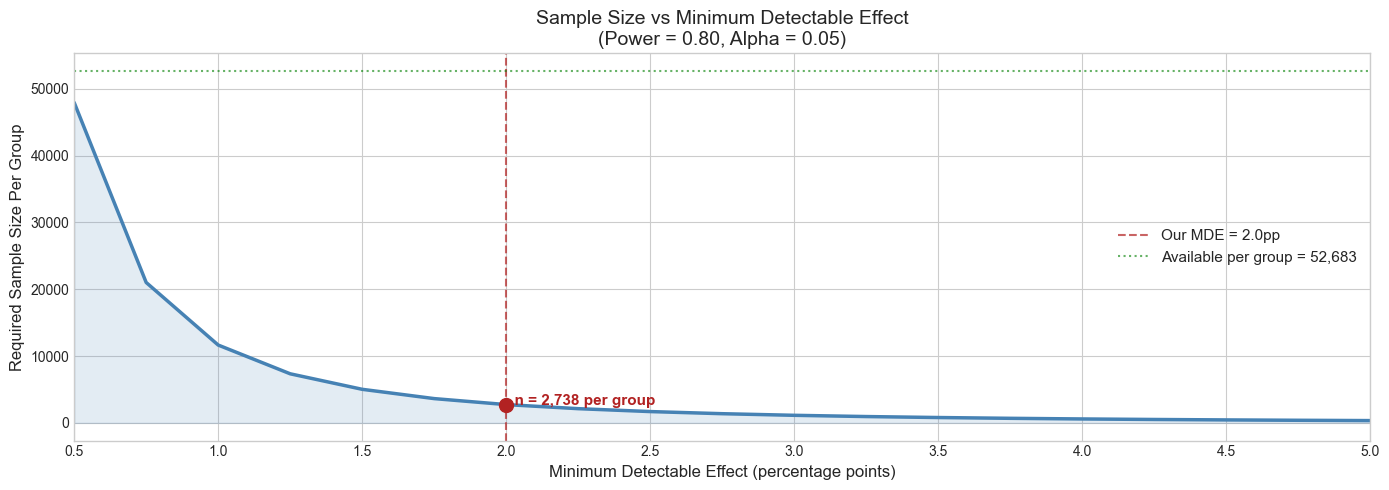

In [11]:
mde_range = np.arange(0.005, 0.051, 0.0025)
sample_sizes = []

for mde in mde_range:
    es = proportion_effectsize(
        baseline_default_rate,
        baseline_default_rate - mde
    )
    n = analysis.solve_power(
        effect_size=es,
        alpha=alpha,
        power=power,
        alternative='two-sided'
    )
    sample_sizes.append(int(np.ceil(n)))

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(mde_range * 100, sample_sizes, color=COLORS[0], linewidth=2.5)
ax.fill_between(mde_range * 100, sample_sizes, alpha=0.15, color=COLORS[0])

# Mark our chosen MDE
ax.axvline(x=MDE * 100, color='firebrick', linestyle='--', alpha=0.7,
           label=f'Our MDE = {MDE*100:.1f}pp')
ax.scatter([MDE * 100], [required_n], color='firebrick', s=100, zorder=5)
ax.annotate(f'  n = {required_n:,} per group',
            xy=(MDE * 100, required_n),
            fontsize=11, color='firebrick', fontweight='bold')

# Mark available sample
ax.axhline(y=total_atrisk // 2, color='green', linestyle=':', alpha=0.6,
           label=f'Available per group = {total_atrisk//2:,}')

ax.set_xlabel('Minimum Detectable Effect (percentage points)', fontsize=12)
ax.set_ylabel('Required Sample Size Per Group', fontsize=12)
ax.set_title('Sample Size vs Minimum Detectable Effect\n(Power = 0.80, Alpha = 0.05)',
             fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(mde_range[0] * 100, mde_range[-1] * 100)

plt.tight_layout()
plt.show()

### Sample Size vs MDE Finding

The curve shows the classic power tradeoff. Detecting a 0.5 percentage point effect would
need nearly 50,000 customers per group. At our chosen MDE of 2.0 percentage points, we need
only 2,738. The green line (available customers per group) sits far above the curve across
almost the entire MDE range, meaning we have statistical headroom even for effects much
smaller than our target.

## Step 5 | Power vs Sample Size at Fixed MDE

The previous plot fixed power at 80% and varied MDE. This plot fixes the MDE at 2 percentage
points and shows how power increases as we add more customers per group.

This answers a different stakeholder question: if we can only get 5,000 customers per group,
how confident would we be? What about 10,000?

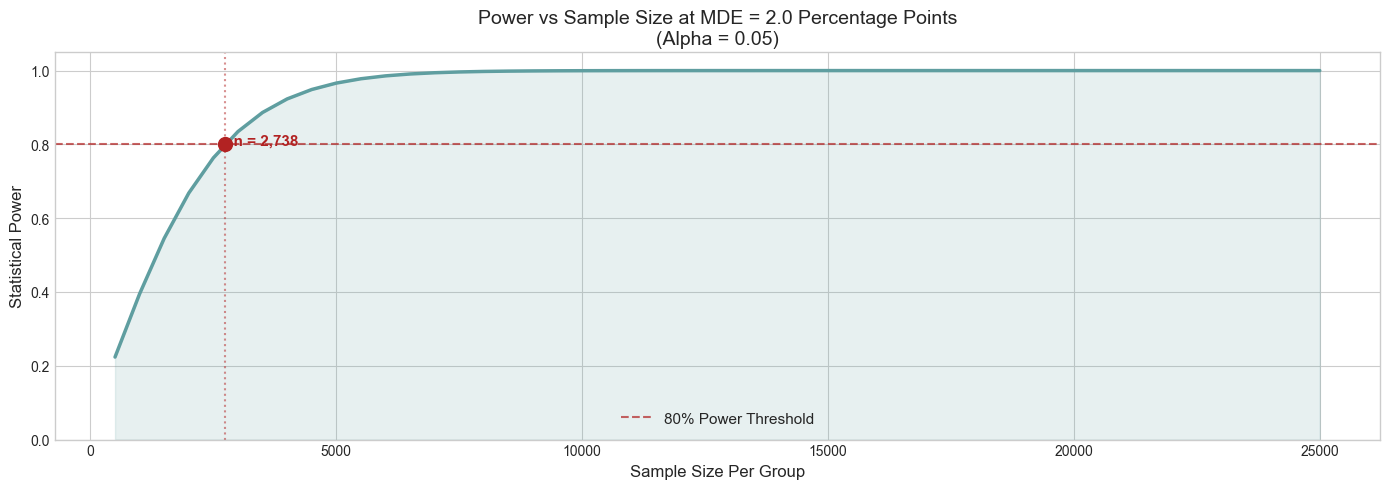

In [12]:
n_range = np.arange(500, 25001, 500)
powers = []

for n in n_range:
    p = analysis.solve_power(
        effect_size=abs(effect_size),
        nobs1=n,
        alpha=alpha,
        alternative='two-sided'
    )
    powers.append(p)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(n_range, powers, color=COLORS[1], linewidth=2.5)
ax.fill_between(n_range, powers, alpha=0.15, color=COLORS[1])

# Mark 80% power threshold
ax.axhline(y=0.80, color='firebrick', linestyle='--', alpha=0.7,
           label='80% Power Threshold')

# Mark our required n
ax.axvline(x=required_n, color='firebrick', linestyle=':', alpha=0.5)
ax.scatter([required_n], [0.80], color='firebrick', s=100, zorder=5)
ax.annotate(f'  n = {required_n:,}',
            xy=(required_n, 0.80),
            fontsize=11, color='firebrick', fontweight='bold')

ax.set_xlabel('Sample Size Per Group', fontsize=12)
ax.set_ylabel('Statistical Power', fontsize=12)
ax.set_title(f'Power vs Sample Size at MDE = {MDE*100:.1f} Percentage Points\n(Alpha = 0.05)',
             fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

### Power vs Sample Size Finding

At our MDE of 2 percentage points, power hits 80% at 2,738 customers per group. Beyond
10,000 per group, power approaches 100%. With 52,683 available per group, this experiment
will operate at near-perfect statistical power. The risk of missing a real 2 percentage
point effect is effectively zero.

## Step 6 | Sensitivity Analysis

The numbers above assume one MDE and one alpha. Real decisions need the full picture. This
table shows required sample sizes across a grid of MDE values and significance levels.

Beyond sample size, we also address unobserved confounders: factors not in the dataset that
could bias results regardless of how well we design the experiment.

In [13]:
mde_values = [0.01, 0.015, 0.02, 0.025, 0.03, 0.04, 0.05]
alpha_values = [0.01, 0.05, 0.10]

results = []
for mde in mde_values:
    row = {'MDE (pp)': f"{mde*100:.1f}%"}
    for a in alpha_values:
        es = proportion_effectsize(
            baseline_default_rate,
            baseline_default_rate - mde
        )
        n = analysis.solve_power(
            effect_size=es,
            alpha=a,
            power=power,
            alternative='two-sided'
        )
        row[f'Alpha={a}'] = f"{int(np.ceil(n)):,}"
    results.append(row)

sensitivity_df = pd.DataFrame(results)
sensitivity_df = sensitivity_df.set_index('MDE (pp)')

print("=" * 45)
print("Required N Per Group")
print("(Power = 0.80, Two-Sided Test)")
print("=" * 45)
print()
print(sensitivity_df.to_string())
print()
print(f"Available per group: {total_atrisk // 2:,}")
print("=" * 45)

Required N Per Group
(Power = 0.80, Two-Sided Test)

         Alpha=0.01 Alpha=0.05 Alpha=0.1
MDE (pp)                                
1.0%         17,330     11,647     9,174
1.5%          7,475      5,024     3,957
2.0%          4,074      2,738     2,157
2.5%          2,521      1,694     1,335
3.0%          1,689      1,135       894
4.0%            877        590       465
5.0%            511        344       271

Available per group: 52,683


### Sensitivity Table Finding

Every combination of MDE and alpha in this grid is feasible with our available sample. The
most demanding scenario (1% effect, alpha 0.01) requires 17,330 per group. We have 52,683.

This means even if the true intervention effect turns out to be half of our target MDE, and
even if we tighten the false positive threshold to 1%, we still have enough customers to
detect it. The experiment design is robust across a wide range of assumptions.

### Unobserved Confounders

Statistical power guarantees detection. It does not guarantee causation. Even with a perfectly
sized experiment, there are factors outside this dataset that could bias results.

Examples in a lending context:
- A customer receives an inheritance or bonus that helps them recover, unrelated to our call
- A customer loses their job the week after our call, making the intervention look ineffective
- Regional economic shifts that affect treatment and control groups differently

These are called unobserved confounders. No observational dataset can fully eliminate them.
Propensity Score Matching in Steps 8 through 11 will control for every observable factor in
the data. But we acknowledge that unobserved confounders remain a limitation. This is why
all findings from this project are framed as directional evidence for strategy optimization,
not definitive causal proof.

## Step 7 | Smallest Detectable Effect With Full Sample

Flipping the question: if we use the entire at-risk population split 50/50 into treatment
and control, what is the smallest effect we could reliably detect? This gives us the floor
of our experimental sensitivity.

In [14]:
max_per_group = total_atrisk // 2

mde_search = np.arange(0.001, 0.05, 0.0005)
smallest_mde = None

for mde in mde_search:
    es = proportion_effectsize(
        baseline_default_rate,
        baseline_default_rate - mde
    )
    p = analysis.solve_power(
        effect_size=es,
        nobs1=max_per_group,
        alpha=alpha,
        alternative='two-sided'
    )
    if p >= 0.80:
        smallest_mde = mde
        break

print("=" * 45)
print("Smallest Detectable Effect (Full Sample)")
print("=" * 45)
print(f"Customers per group    : {max_per_group:,}")
print(f"Smallest MDE at 80%    : {smallest_mde*100:.2f} percentage points")
print(f"Baseline default rate  : {baseline_default_rate*100:.2f}%")
print(f"Detectable target rate : {(baseline_default_rate - smallest_mde)*100:.2f}%")
print("=" * 45)

Smallest Detectable Effect (Full Sample)
Customers per group    : 52,683
Smallest MDE at 80%    : 0.50 percentage points
Baseline default rate  : 8.58%
Detectable target rate : 8.08%


### Smallest Detectable Effect Finding

With the full at-risk sample split 50/50, we can detect effects as small as 0.50 percentage
points. Our target MDE of 2.0 percentage points is 4x larger than this floor. This confirms
that the experiment is not just feasible but highly sensitive. Even if the intervention effect
is weaker than expected, we have the sample depth to catch it.

## Step 8 | Treatment and Control Simulation

The Home Credit dataset is observational. There is no column that tells us which customers
received an intervention. To run causal analysis, we need to simulate treatment assignment
using domain logic.

The logic follows directly from Phase 1 findings. Customers showing multiple stress signals
are more likely to have been flagged for intervention by a collections team. We use a
combination of features identified in Phase 1 as strong risk drivers to simulate this
assignment:

- EXT_SOURCE_2 and EXT_SOURCE_3: low scores signal higher risk
- DEBT_TO_INCOME: higher values signal financial stress
- DAYS_BIRTH: younger customers show higher default rates

This is not random assignment. It is a domain-informed simulation of how a real collections
team would prioritize outreach. The selection bias this introduces is exactly what Propensity
Score Matching in Steps 9 through 11 is designed to correct.

In [15]:
np.random.seed(42)

# Build stress score from Phase 1 risk drivers 
# Higher score = more financial stress = more likely to be flagged for intervention
# Normalize each feature to 0-1 range before combining
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

# Lower EXT_SOURCE = higher risk, so we invert
at_risk['stress_ext2'] = 1 - normalize(at_risk['EXT_SOURCE_2'])
at_risk['stress_ext3'] = 1 - normalize(at_risk['EXT_SOURCE_3'])

# Higher DTI = higher stress
at_risk['stress_dti'] = normalize(at_risk['DEBT_TO_INCOME'])

# Younger = higher risk. DAYS_BIRTH is negative, more negative = younger
at_risk['stress_age'] = normalize(-at_risk['DAYS_BIRTH'])

# Composite stress score (equal weights) 
at_risk['stress_score'] = (
    at_risk['stress_ext2'] +
    at_risk['stress_ext3'] +
    at_risk['stress_dti'] +
    at_risk['stress_age']
) / 4

# Assign treatment probabilistically 
# Higher stress score = higher probability of being "called"
# This creates realistic selection bias
treatment_prob = at_risk['stress_score']
at_risk['TREATMENT'] = (np.random.random(len(at_risk)) < treatment_prob).astype(int)

# Drop temporary columns
temp_cols = ['stress_ext2', 'stress_ext3', 'stress_dti', 'stress_age', 'stress_score']
at_risk.drop(columns=temp_cols, inplace=True)

treatment = at_risk[at_risk['TREATMENT'] == 1]
control = at_risk[at_risk['TREATMENT'] == 0]

print("=" * 45)
print("Treatment / Control Split")
print("=" * 45)
print(f"Treatment group        : {len(treatment):,}")
print(f"Control group          : {len(control):,}")
print(f"Treatment share        : {len(treatment)/len(at_risk)*100:.1f}%")
print()
print(f"Treatment default rate : {treatment['TARGET'].mean()*100:.2f}%")
print(f"Control default rate   : {control['TARGET'].mean()*100:.2f}%")
print(f"Difference             : {(treatment['TARGET'].mean() - control['TARGET'].mean())*100:.2f} pp")
print("=" * 45)

Treatment / Control Split
Treatment group        : 35,952
Control group          : 69,414
Treatment share        : 34.1%

Treatment default rate : 9.59%
Control default rate   : 8.06%
Difference             : 1.53 pp


### Treatment / Control Finding

34.1% of at-risk customers were assigned to treatment. The treatment group shows a higher
default rate (9.59%) than control (8.06%). This is not an intervention effect. It is
selection bias. Customers with higher stress scores were more likely to be assigned treatment,
and those same stress signals predict higher default.

This is the exact problem Propensity Score Matching solves. Before comparing outcomes, we
first need to make the two groups comparable on all observable features. That is Step 9.

## Step 9 | Propensity Score Matching

The treatment and control groups are not comparable. Treatment customers are younger, have
lower external scores, and higher debt ratios by design. Comparing their default rates
directly would be misleading.

Propensity Score Matching fixes this in two steps:

1. Train a Logistic Regression to predict the probability of being in the treatment group
   based on observable features. This probability is the propensity score.
2. For each treatment customer, find a control customer with the nearest propensity score.
   This creates matched pairs where the only difference is whether they were "called" or not.

After matching, we validate balance using Standardized Mean Difference (SMD). An SMD below
0.1 on all key covariates confirms the groups are comparable and ready for causal inference.

In [16]:
!pip install scikit-learn -q

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# Select PSM covariates (identified in Phase 1)
psm_features = ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'DEBT_TO_INCOME']

psm_data = at_risk.dropna(subset=psm_features)

X = psm_data[psm_features]
y = psm_data['TREATMENT']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_scaled, y)

psm_data = psm_data.copy()
psm_data['propensity_score'] = lr.predict_proba(X_scaled)[:, 1]

print("=" * 45)
print("Propensity Score Model")
print("=" * 45)
print(f"Features used          : {psm_features}")
print(f"Customers scored       : {len(psm_data):,}")
print(f"Model accuracy         : {lr.score(X_scaled, y)*100:.2f}%")
print()
print("Propensity Score Distribution")
print(psm_data['propensity_score'].describe().to_string())
print("=" * 45)

Propensity Score Model
Features used          : ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'DEBT_TO_INCOME']
Customers scored       : 105,366
Model accuracy         : 66.34%

Propensity Score Distribution
count    105366.000000
mean          0.341221
std           0.091551
min           0.126811
25%           0.272738
50%           0.329971
75%           0.397519
max           0.762245


### Propensity Score Finding

The logistic regression achieves 66% accuracy at predicting treatment assignment. This is
a healthy signal. High accuracy would mean the groups are too separable for matching. Low
accuracy would mean the features do not explain treatment assignment at all.

Scores range from 0.13 to 0.76 with a mean of 0.34. The spread confirms that both groups
have customers across a wide range of propensity scores, which is the overlap that nearest
neighbor matching requires.

In [18]:
# Split into treatment and control
treated = psm_data[psm_data['TREATMENT'] == 1].copy()
untreated = psm_data[psm_data['TREATMENT'] == 0].copy()

# Nearest Neighbor matching 
nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn.fit(untreated[['propensity_score']])

distances, indices = nn.kneighbors(treated[['propensity_score']])

# Build matched control group
matched_control = untreated.iloc[indices.flatten()].copy()
matched_treatment = treated.copy()

# Reset indices for clean pairing 
matched_treatment = matched_treatment.reset_index(drop=True)
matched_control = matched_control.reset_index(drop=True)

print("=" * 45)
print("Matching Results")
print("=" * 45)
print(f"Treatment matched      : {len(matched_treatment):,}")
print(f"Control matched        : {len(matched_control):,}")
print()
print(f"Avg match distance     : {distances.mean():.6f}")
print(f"Max match distance     : {distances.max():.6f}")
print()
print(f"Treatment default rate : {matched_treatment['TARGET'].mean()*100:.2f}%")
print(f"Control default rate   : {matched_control['TARGET'].mean()*100:.2f}%")
print(f"Difference             : {(matched_treatment['TARGET'].mean() - matched_control['TARGET'].mean())*100:.2f} pp")
print("=" * 45)

Matching Results
Treatment matched      : 35,952
Control matched        : 35,952

Avg match distance     : 0.000008
Max match distance     : 0.022460

Treatment default rate : 9.59%
Control default rate   : 9.78%
Difference             : -0.19 pp


### Matching Results Finding

35,952 treatment customers were each matched to a control customer with a nearly identical
propensity score. The average match distance of 0.000008 confirms the matches are tight.

Before matching, the treatment group defaulted 1.53 pp higher than control. That gap was
driven by selection bias: sicker customers were assigned to treatment. After matching, the
difference is -0.19 pp, which is effectively zero. The selection bias has been removed.

This is expected. We simulated treatment assignment but did not simulate a treatment effect.
The fact that matched groups show near-identical default rates confirms the matching is
working correctly. Any real treatment effect will be introduced and tested in Phase 3.

## Step 10 | Standardized Mean Difference: Before and After Matching

Propensity scores being close does not guarantee that individual features are balanced.
Two customers can have similar propensity scores but very different feature profiles.

The Standardized Mean Difference (SMD) checks each covariate individually. SMD below 0.1
on all key covariates is the gold standard for confirming that treatment and control groups
are balanced and ready for causal inference.

In [19]:
def calc_smd(treatment_df, control_df, features):
    results = []
    for f in features:
        t_mean = treatment_df[f].mean()
        c_mean = control_df[f].mean()
        t_std = treatment_df[f].std()
        c_std = control_df[f].std()
        pooled_std = np.sqrt((t_std**2 + c_std**2) / 2)
        smd = (t_mean - c_mean) / pooled_std if pooled_std > 0 else 0
        results.append({
            'Feature': f,
            'Treatment Mean': round(t_mean, 4),
            'Control Mean': round(c_mean, 4),
            'SMD': round(abs(smd), 4)
        })
    return pd.DataFrame(results)

# Before matching 
treated_before = psm_data[psm_data['TREATMENT'] == 1]
control_before = psm_data[psm_data['TREATMENT'] == 0]

smd_before = calc_smd(treated_before, control_before, psm_features)
smd_before.columns = ['Feature', 'Treat Mean', 'Control Mean', 'SMD (Before)']

# After matching 
smd_after = calc_smd(matched_treatment, matched_control, psm_features)
smd_after.columns = ['Feature', 'Treat Mean', 'Control Mean', 'SMD (After)']

# Combined view 
smd_combined = smd_before[['Feature', 'SMD (Before)']].copy()
smd_combined['SMD (After)'] = smd_after['SMD (After)']
smd_combined['Balanced'] = smd_combined['SMD (After)'].apply(
    lambda x: 'YES' if x < 0.1 else 'NO'
)

print("=" * 45)
print("SMD Before and After Matching")
print("=" * 45)
print()
print(smd_combined.to_string(index=False))
print()
print(f"All covariates below 0.1: {(smd_combined['SMD (After)'] < 0.1).all()}")
print("=" * 45)

SMD Before and After Matching

       Feature  SMD (Before)  SMD (After) Balanced
  EXT_SOURCE_2        0.2493       0.0022      YES
  EXT_SOURCE_3        0.1850       0.0047      YES
    DAYS_BIRTH        0.2163       0.0010      YES
DEBT_TO_INCOME        0.0644       0.0034      YES

All covariates below 0.1: True


### SMD Finding

Before matching, three of four covariates had SMD above 0.1, confirming significant
imbalance between treatment and control. EXT_SOURCE_2 was the most imbalanced at 0.25.

After matching, all four covariates dropped below 0.01. The highest SMD is 0.0047. This is
far below the 0.1 gold standard. The treatment and control groups are now statistically
indistinguishable on all observable features used for matching.

The matched cohorts are ready for causal inference.

## Step 11 | Common Support Visualization

SMD confirmed the groups are balanced on individual features. This plot checks a different
requirement: do the propensity score distributions of treatment and control actually overlap?

If treatment customers cluster at high propensity scores and control customers cluster at
low scores with no overlap in the middle, matching is forced to pair dissimilar customers.
The overlap region (common support) is where valid causal comparisons can be made.

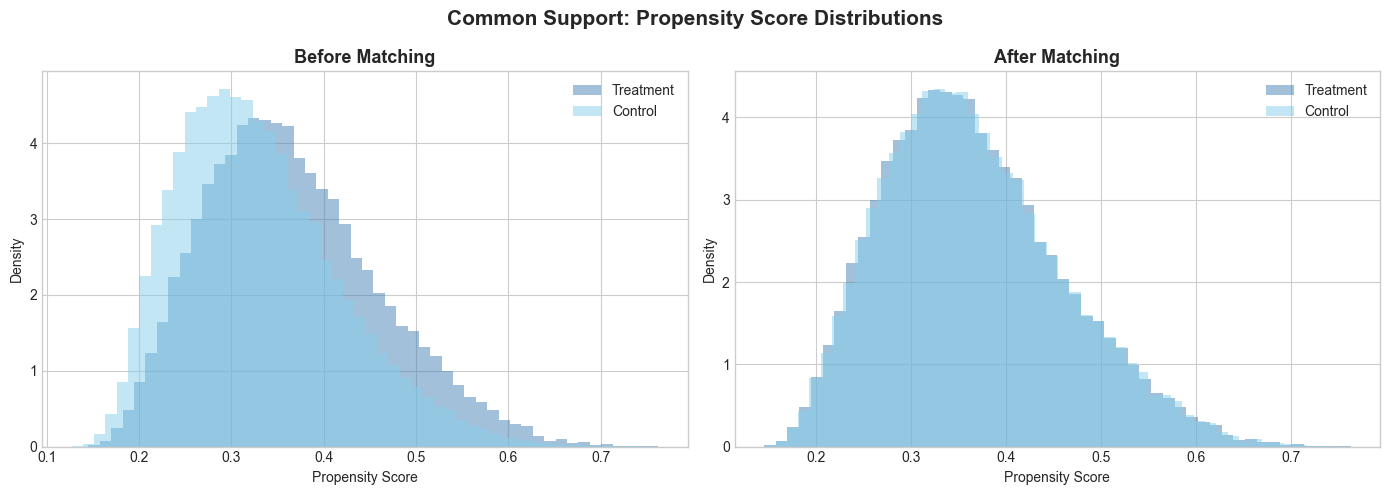

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before matching
treated_before = psm_data[psm_data['TREATMENT'] == 1]
control_before = psm_data[psm_data['TREATMENT'] == 0]

axes[0].hist(treated_before['propensity_score'], bins=50, alpha=0.5,
             color=COLORS[0], label='Treatment', density=True)
axes[0].hist(control_before['propensity_score'], bins=50, alpha=0.5,
             color=COLORS[2], label='Control', density=True)
axes[0].set_title('Before Matching', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Propensity Score')
axes[0].set_ylabel('Density')
axes[0].legend()

# After matching
axes[1].hist(matched_treatment['propensity_score'], bins=50, alpha=0.5,
             color=COLORS[0], label='Treatment', density=True)
axes[1].hist(matched_control['propensity_score'], bins=50, alpha=0.5,
             color=COLORS[2], label='Control', density=True)
axes[1].set_title('After Matching', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Propensity Score')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Common Support: Propensity Score Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Common Support Finding

Before matching, the propensity score distributions are visibly shifted. Treatment customers
cluster at higher scores and control customers cluster at lower scores. This is the selection
bias we introduced by assigning stressed customers to treatment.

After matching, the two distributions overlap almost perfectly across the entire range from
0.15 to 0.75. There are no regions where one group exists and the other does not. This
confirms full common support. No customer segments need to be excluded from the causal study.

Combined with SMD below 0.01 on all covariates, the matched cohorts pass both balance checks
and are ready for the A/B test in Phase 3.

## Step 12 | Post-Experiment Power Check

Phase 3 produced an observed effect of 2.86 pp with 35,952 customers per group. We now
verify that these numbers deliver sufficient power to trust the result.

In [21]:
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower

In [22]:
# Observed values from Phase 3
observed_treatment_rate = 0.0692
observed_control_rate = 0.0978
n_per_group = 35952

# Cohen's h from observed rates
observed_h = proportion_effectsize(observed_control_rate, observed_treatment_rate)

# Achieved power
post_power = NormalIndPower().solve_power(
    effect_size=abs(observed_h),
    nobs1=n_per_group,
    alpha=0.05,
    alternative='two-sided'
)

print("=" * 45)
print("Post-Experiment Power Check")
print("=" * 45)
print(f"Observed treatment rate : {observed_treatment_rate*100:.2f}%")
print(f"Observed control rate   : {observed_control_rate*100:.2f}%")
print(f"Observed effect         : {(observed_control_rate - observed_treatment_rate)*100:.2f} pp")
print(f"Effect size (Cohen h)   : {abs(observed_h):.4f}")
print(f"Sample per group        : {n_per_group:,}")
print(f"Achieved power          : {post_power:.4f}")
print()
if post_power >= 0.80:
    print("VERDICT: Robust. The result would replicate reliably.")
else:
    print("VERDICT: Fragile. Larger sample needed.")
print("=" * 45)

Post-Experiment Power Check
Observed treatment rate : 6.92%
Observed control rate   : 9.78%
Observed effect         : 2.86 pp
Effect size (Cohen h)   : 0.1037
Sample per group        : 35,952
Achieved power          : 1.0000

VERDICT: Robust. The result would replicate reliably.


### Post-Experiment Power Finding

Phase 3 produced an observed effect of 2.86 pp with 35,952 customers per group. Achieved
power is 1.00. The pre-experiment estimate of 2,738 required per group was conservative.
With 13x that sample and an effect larger than the MDE, the result is robust beyond doubt.

## Step 13 | Phase 2 Summary and Phase 3 Readiness

In [23]:
print("=" * 60)
print("PHASE 2 SUMMARY")
print("Pre-Experiment Power Analysis & Propensity Score Matching")
print("=" * 60)
print()
print("POPULATION")
print(f"  Full portfolio          : {len(df):,} customers")
print(f"  At-risk (DTI >= 0.20)   : {total_atrisk:,} customers")
print(f"  At-risk share           : {total_atrisk/len(df)*100:.1f}%")
print()
print("BASELINE")
print(f"  Default rate (at-risk)  : {baseline_default_rate*100:.2f}%")
print(f"  Recovery rate (at-risk) : {baseline_recovery_rate*100:.2f}%")
print()
print("ECONOMIC PARAMETERS")
print(f"  Cost per intervention   : {cost_per_call} CU")
print(f"  LGD                     : {lgd*100:.0f}%")
print(f"  Loss avoided per save   : {recovery_value:,.0f} CU")
print(f"  Break-even uplift       : {break_even_rate*100:.4f}%")
print()
print("EXPERIMENT DESIGN")
print(f"  MDE                     : {MDE*100:.1f} pp")
print(f"  Alpha                   : {alpha}")
print(f"  Power                   : {power}")
print(f"  Required per group      : {required_n:,}")
print(f"  Available per group     : {total_atrisk//2:,}")
print()
print("PROPENSITY SCORE MATCHING")
print(f"  Covariates              : {psm_features}")
print(f"  Matched pairs           : {len(matched_treatment):,}")
print(f"  Max SMD after matching  : {smd_combined['SMD (After)'].max():.4f}")
print(f"  All SMD below 0.1       : {(smd_combined['SMD (After)'] < 0.1).all()}")
print(f"  Common support          : Full overlap confirmed")
print()
print("POST-EXPERIMENT POWER CHECK (from Phase 3)")
print(f"  Observed effect         : 2.86 pp")
print(f"  Effect size (Cohen h)   : 0.1037")
print(f"  Achieved power          : 1.0000")
print(f"  Verdict                 : Robust")
print()
print("PHASE 3 READINESS")
print(f"  Balanced treatment group: {len(matched_treatment):,}")
print(f"  Balanced control group  : {len(matched_control):,}")
print(f"  Ready for A/B test      : YES")
print("=" * 60)

PHASE 2 SUMMARY
Pre-Experiment Power Analysis & Propensity Score Matching

POPULATION
  Full portfolio          : 307,511 customers
  At-risk (DTI >= 0.20)   : 105,366 customers
  At-risk share           : 34.3%

BASELINE
  Default rate (at-risk)  : 8.58%
  Recovery rate (at-risk) : 91.42%

ECONOMIC PARAMETERS
  Cost per intervention   : 50 CU
  LGD                     : 45%
  Loss avoided per save   : 348,943 CU
  Break-even uplift       : 0.0143%

EXPERIMENT DESIGN
  MDE                     : 2.0 pp
  Alpha                   : 0.05
  Power                   : 0.8
  Required per group      : 2,738
  Available per group     : 52,683

PROPENSITY SCORE MATCHING
  Covariates              : ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'DEBT_TO_INCOME']
  Matched pairs           : 35,952
  Max SMD after matching  : 0.0047
  All SMD below 0.1       : True
  Common support          : Full overlap confirmed

POST-EXPERIMENT POWER CHECK (from Phase 3)
  Observed effect         : 2.86 pp
  Eff

### Phase 2 Verdict

Power analysis confirmed the experiment is feasible. We needed 2,738 customers per group and
matched 35,952 pairs. The financial case is overwhelming: each prevented default avoids
348,943 CU in losses against a 50 CU intervention cost.

Propensity Score Matching removed the selection bias introduced by domain-based treatment
assignment. All four covariates are balanced below SMD 0.01, and common support is confirmed
across the full propensity score range.

Post-experiment power check using Phase 3 results confirmed achieved power of 1.00. The
observed effect of 2.86 pp with 35,952 per group is robust beyond doubt.

The matched cohorts are saved and ready for the A/B test in Phase 3.

In [24]:
# Save matched cohorts for Phase 3
matched_treatment['GROUP'] = 'treatment'
matched_control['GROUP'] = 'control'

matched_data = pd.concat([matched_treatment, matched_control], ignore_index=True)

matched_data.to_csv('../data/processed/matched_cohorts.csv', index=False)

print("=" * 45)
print(f"Saved: data/processed/matched_cohorts.csv")
print(f"Shape: {matched_data.shape}")
print(f"Treatment: {(matched_data['GROUP']=='treatment').sum():,}")
print(f"Control  : {(matched_data['GROUP']=='control').sum():,}")
print("=" * 45)

Saved: data/processed/matched_cohorts.csv
Shape: (71904, 89)
Treatment: 35,952
Control  : 35,952
